In [1]:
# === Environment Setup ===
import os
os.environ['R_HOME'] = "/home/WLJ/anaconda3/envs/R4.2/lib/R"

import warnings
warnings.filterwarnings("ignore")

import scanpy as sc
from tqdm import tqdm
from torch.optim.lr_scheduler import ExponentialLR
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import normalized_mutual_info_score, homogeneity_score, completeness_score

from scipy.sparse import coo_matrix

from model.OrthoST import OrthoST
from model.EBF import gaussian_smoothing_pipeline
from model.utils.utils import *
from model.utils.clustering import *
from model.utils.losses import *
from model.earlystop import EarlyStop

In [2]:
def log_gpu_memory(reset_peak=False):
    """Log current and peak GPU memory usage."""
    if not torch.cuda.is_available():
        print(f"CUDA not available")
        return
    if reset_peak:
        torch.cuda.reset_peak_memory_stats()
    else:
        torch.cuda.synchronize()
        allocated = torch.cuda.memory_allocated(1) / (1024 ** 2)
        peak = torch.cuda.max_memory_allocated(1) / (1024 ** 2)
        print(f"[GPU] Current: {allocated:.1f} MB | Peak: {peak:.1f} MB")

def evaluate(adata, label_key, n_cluster):
    """
    Evaluate embeddings using clustering.
    """
    adata = mclust_R(adata, used_obsm="OrthoST", key_added="OrthoST_Mclust", num_cluster=n_cluster, random_seed=0)
    pred = adata.obs["OrthoST_Mclust"]
    gt = adata.obs[label_key]

    nmi = normalized_mutual_info_score(gt, pred)
    hom = homogeneity_score(gt, pred)
    com = completeness_score(gt, pred)

    print(f"[Result] NMI: {nmi:.3f} | HOM: {hom:.3f} | COM: {com:.3f}")
    return nmi, hom, com

In [3]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)

# -------- Paths & Config --------
method = "OrthoST"
dataset = "3-HBRCA"
label_key = "fine_annot_type"
result_dir = f"/home/WLJ/CAST/Results/{dataset}/OrthoST"
model_dir = os.path.join(result_dir, "models")
os.makedirs(model_dir, exist_ok=True)

# -------- Hyperparameters --------
theta = 0.6     # spatial-feature balance
alpha_1 = 0.1   # reconstruction vs Laplacian
alpha_2 = 0.1   # contrastive vs Laplacian

res_df = pd.DataFrame(index = [], columns=['NMI', 'HOM', 'COM'])

cuda:1


In [4]:
for seed in [0, 2, 4, 8, 16]:
    set_seed(seed)
    model_path = os.path.join(model_dir, f"{dataset}_seed{seed}_model.pth")
    train_es = EarlyStop(model_path, patience=50, delta=1e-4)

    # -------- Load Data & Preprocessing --------
    adata = sc.read_h5ad(f'/home/WLJ/CAST/Dataset/{dataset}/{dataset}.h5ad')
    adata.var_names_make_unique()
    n_cluster = len(set(adata.obs[label_key].values))
    print(f"[Data] {dataset} | Shape: {adata.shape}")
    if seed==0: log_gpu_memory(reset_peak=True)
    # Build Spatial Graph
    spatial_graph, spatial_dist = generate_spatial_graph(adata, k_cutoff=6, model="KNN")
    spatial_graph_large, spatial_dist_large = generate_spatial_graph(adata, k_cutoff=18, model="KNN")
    # Gene filtering
    sc.pp.filter_genes(adata, min_cells=10)
    gene_mask = np.asarray([not str(name).lower().startswith("ercc") for name in adata.var_names])
    adata._inplace_subset_var(gene_mask)
    adata.layers['counts'] = adata.X.copy()
    # Normalization
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    # HVG selection
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer="counts", n_top_genes=3000)
    adata = adata[:, adata.var['highly_variable']]
    smoothed_adata = adata.copy()
    # PCA
    sc.pp.scale(adata, zero_center=False, max_value=10)  # max_value=10
    sc.pp.pca(adata, n_comps=25, random_state=seed)
    X_pca = adata.obsm['X_pca']

    # -------- EBF augmentation --------
    edge_row, edge_col = np.where(spatial_graph_large == 1)
    feature_edge_dist = np.sqrt(np.sum((X_pca[edge_row] - X_pca[edge_col]) ** 2, axis=1))
    feature_dist_matrix = coo_matrix((feature_edge_dist, (edge_row, edge_col)),
                                     shape=spatial_graph_large.shape).toarray()
    smoothed_adata.X = gaussian_smoothing_pipeline(smoothed_adata.X.toarray(), spatial_graph_large, spatial_dist_large, feature_dist_matrix, theta)
    sc.pp.scale(smoothed_adata, zero_center=False, max_value=10)
    sc.pp.pca(smoothed_adata, n_comps=25, random_state=seed)
    feature_graph = generate_feature_graph(smoothed_adata, k_cutoff=6, use_data="X_pca")

    # -------- Model preparation --------
    raw_data = torch.tensor(adata.X.toarray(), dtype=torch.float32).to(device)
    smooth_data = torch.tensor(smoothed_adata.X, dtype=torch.float32).to(device)
    hybrid_graph = torch.tensor((1 - theta) * spatial_graph + theta * feature_graph,
                                dtype=torch.float32).to(device)

    spatial_coord = torch.tensor(adata.obsm["spatial"], dtype=torch.float32).to(device)
    spatial_neighbors = query_ball_point(n_sample=6, location=spatial_coord, quartile=0.01)

    model = OrthoST(adata.n_vars, 128, 32).to(device)
    n_epochs = 500
    mask_ratio = 0.5
    scaler = GradScaler()

    ae_optimizer = torch.optim.Adam(model.parameters(), lr=0.0025, weight_decay=1e-5)
    ae_scheduler = ExponentialLR(ae_optimizer, gamma=0.995)
    cl_optimizer = torch.optim.Adam(list(model.encoder.parameters()) + list(model.cl_proj.parameters()),
                                    lr=0.0025, weight_decay=1e-5)
    cl_scheduler = ExponentialLR(cl_optimizer, gamma=0.995)
    contrastive_loss_fn = InfoNCE(temperature=0.07, negative_mode="paired")

    epoch_bar = tqdm(range(1, n_epochs + 1), desc=f"Training", unit="epoch")
    for epoch in epoch_bar:
        mask = (torch.rand_like(raw_data) < mask_ratio).to(device)
        masked_input = mask.float() * raw_data + (~mask).float() * smooth_data
        random_neighbors = query_random_point(num_samples=adata.n_obs, n_sample=6)

        model.train()
        # ---------------- Reconstruction task ----------------
        ae_optimizer.zero_grad()
        with autocast():
            h, z, recon = model.forward_indiv(raw_data[spatial_neighbors])

            loss_rec = F.mse_loss(recon, raw_data)
            loss_lap = compute_laplacian_loss(z, hybrid_graph)
            loss_1 = (1 - alpha_1) * loss_rec + alpha_1 * loss_lap
        scaler.scale(loss_1).backward()
        scaler.step(ae_optimizer)
        scaler.update()
        ae_scheduler.step()

        # ---------------- Contrastive learning task ----------------
        cl_optimizer.zero_grad()
        with autocast():
            z_anchor, z_pos, z_neg = model.forward_cl(smooth_data[spatial_neighbors], masked_input[spatial_neighbors],
                                                      smooth_data[random_neighbors])

            loss_cl = contrastive_loss_fn(z_anchor, z_pos, z_neg[spatial_neighbors])
            loss_lap = compute_laplacian_loss(z_anchor, hybrid_graph)

            loss_2 = (1 - alpha_2) * loss_cl + alpha_2 * loss_lap

        scaler.scale(loss_2).backward()
        scaler.step(cl_optimizer)
        scaler.update()
        cl_scheduler.step()

        # ---- Early stopping ----
        train_es((loss_1 + loss_2), model)
        if train_es.early_stop:
            print(f"[EarlyStop] Epoch {epoch}")
            break

    # ---------------- Evaluation ----------------
    if seed==0: log_gpu_memory()
    model.load_state_dict(torch.load(model_path))
    model.eval()

    embedding, _ = model.get_emb(raw_data[spatial_neighbors])
    adata.obsm["OrthoST"] = embedding.cpu().detach().numpy()
    res_df.loc[seed, :] = evaluate(adata, label_key, n_cluster)
    embedding_df = pd.DataFrame(adata.obsm['OrthoST'], index=adata.obs.index)
    embedding_df.to_csv(os.path.join(result_dir, f"{dataset}_seed{seed}_embedding.csv"))


===== Seed 0 =====
[Data] 3-HBRCA | Shape: (3798, 36601)


Training: 100%|██████████| 500/500 [00:30<00:00, 16.19epoch/s]


[GPU] Current: 331.4 MB | Peak: 3942.5 MB


sh: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
sh: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
During startup - Warning messages:
1: Setting LC_CTYPE failed, using "C" 
2: Setting LC_COLLATE failed, using "C" 
3: Setting LC_TIME failed, using "C" 
4: Setting LC_MESSAGES failed, using "C" 
5: Setting LC_MONETARY failed, using "C" 
6: Setting LC_PAPER failed, using "C" 
7: Setting LC_MEASUREMENT failed, using "C" 
R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
[Result] NMI: 0.718 | HOM: 0.739 | COM: 0.698

===== Seed 2 =====
[Data] 3-HBRCA | Shape: (3798, 36601)


...

Training: 100%|██████████| 500/500 [00:30<00:00, 16.15epoch/s]

fitting ...
  |                                                                      |   0%

  |======================================================================| 100%
[Result] NMI: 0.690 | HOM: 0.712 | COM: 0.668

===== Seed 16 =====
[Data] 3-HBRCA | Shape: (3798, 36601)


Training: 100%|██████████| 500/500 [00:44<00:00, 11.14epoch/s]


fitting ...
  |======================================================================| 100%
[Result] NMI: 0.708 | HOM: 0.730 | COM: 0.687


In [5]:
mean_vals = res_df.mean(axis=0)
var_vals = res_df.var(axis=0)

summary_df = pd.DataFrame({
    'Mean': mean_vals,
    'Variance': var_vals
})
print(f"[{dataset} | Summary across all seeds]")
print(res_df)
print("\n[Mean and Variance of Evaluation Metrics]")
print(summary_df.round(4))

[3-HBRCA | Summary across all seeds]
         NMI       HOM       COM
0   0.717778   0.73926  0.697509
2   0.703312  0.725356  0.682569
4    0.71777  0.738928  0.697791
8   0.689635  0.712203  0.668454
16  0.707918   0.72997  0.687159

[Mean and Variance of Evaluation Metrics]
       Mean  Variance
NMI  0.7073    0.0001
HOM  0.7291    0.0001
COM  0.6867    0.0001


fitting ...
  |======================================================================| 100%
[Result] NMI: 0.718 | HOM: 0.739 | COM: 0.698


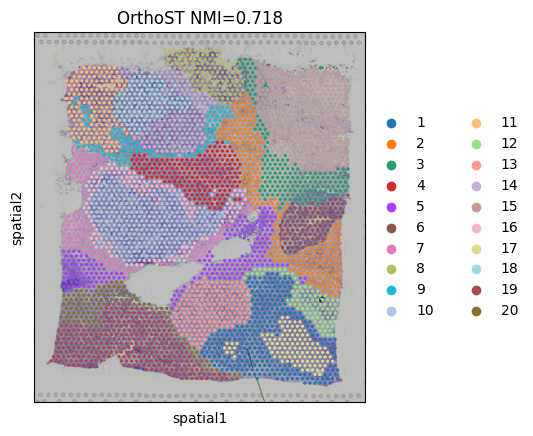

In [6]:
adata = sc.read_h5ad(f'/home/WLJ/CAST/Dataset/{dataset}/{dataset}.h5ad')
adata.var_names_make_unique()

seed = 0
np.random.seed(seed)
emb_df = pd.read_csv(os.path.join(result_dir, f"{dataset}_seed{seed}_embedding.csv"), index_col=0)

adata.obsm["OrthoST"] = emb_df.values
metrics = evaluate(adata, label_key, n_cluster)

sc.pl.spatial(adata, img_key="hires", color="OrthoST_Mclust",
              title=f"{method} NMI={metrics[0]:.3f}",
              legend_fontsize=10, ncols=3)